# Example 

In this notebook a simple case is presented in order to show the general scheme which has been followed 

In [5]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras

from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)


Ray module not found. Multiprocessing features are not available


True

In [6]:
# For reproducibility purposes , we set the seed to a fixed number
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

In [7]:
# The high fidelity (true) function and the low fidelity (noisy version) function are introduced 
highfid = lambda x: np.sin(x)+0.5*np.sin(2*x)+0.3*np.sin(3*x)
lowfid=lambda x:highfid(x)+0.2*np.sin(20*x)+0.1*np.sin(10*x)+0.1*np.sin(30*x)-0.4*np.sin(3*x)


Nhf = 7 # number of points to train the High Fidelity model
Nlf = 30 # number of points to train the Low Fidelity model
N = Nhf + Nlf

# training and test data
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)

# number of epochs
NepoLF = 2000
NepoHF = 750

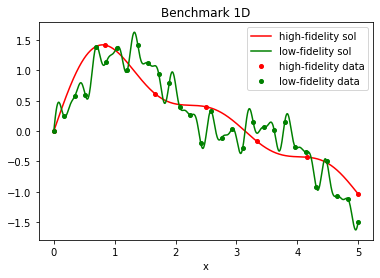

In [8]:
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

The low fidelity model can be seen as a noised version of the high fidelity model. In general, the data from a low fidelity model are easier or less expensive to be obtained

# Low-fidelity model

The function training took 9.927980661392212 seconds.


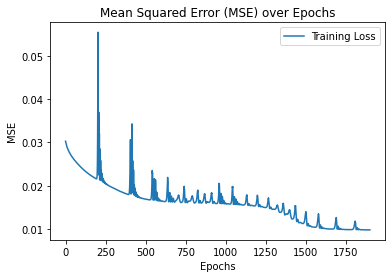

Test MSE: 0.09631736770088165
R^2: 0.783431241006793


In [9]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'} 
modelLF=NetworkFactory.build_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False) # Neural_network is the class that contains all the informations and the functions related to a Neural Network
yLF=modelLF.prediction(x_test) # associates to x_test the correspondent prediction of y using LF model
(mse_LF,R_LF)=modelLF.performance(x_test,highfid(x_test)) # quality test of the model

# High-fidelity model

The function training took 4.534467697143555 seconds.


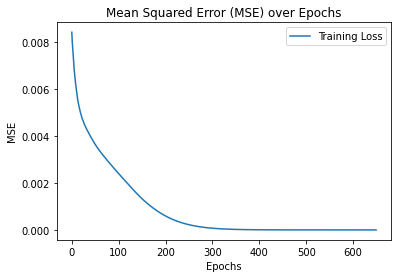

Test MSE: 0.08387006883936794
R^2: 0.811418883646978


In [10]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=NetworkFactory.build_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
(mse_HF,R_HF)=modelHF.performance(x_test,highfid(x_test)) 

# 2 steps model 

The function training took 9.663615942001343 seconds.


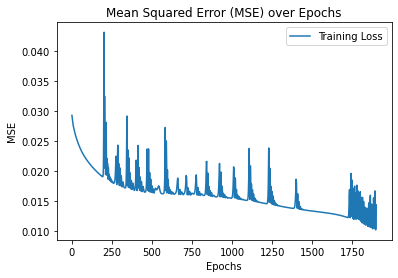

The function training took 3.4369802474975586 seconds.


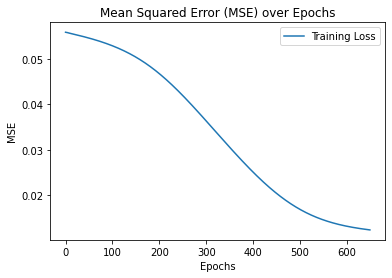

Test MSE: 0.014878760345169849
R^2: 0.9665452374766127


In [11]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','HF']

params=[bestLF_params,best_params]
final_model=NetworkFactory.build_network("2step",names,params=params,data_train=[xlf,xhf],output_train=[Ylf,Yhf],N=N,n=n,do_HPO=False,verbose=False) # Multifidelity connects different neural network classes, to build a multifidelity model
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
(mse_MF,R_MF)=final_model.model_list[1].performance(input_HF,highfid(x_test))

Text(0.5, 1.0, 'High fidelity model - 2-step')

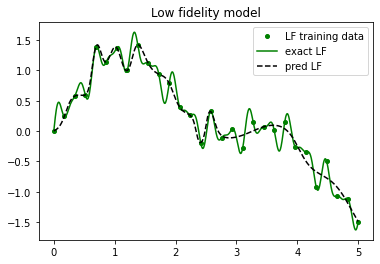

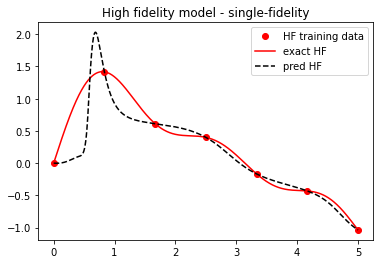

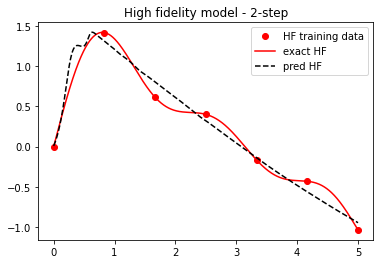

In [12]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

It is possible to notice that the 2 steps neural network has a better approximation of the original function w.r.t. the high fidelity model alone

## Markov Chain Monte Carlo

The Markov Chain Monte Carlo method, using Metropolis Hastings algorithm, is introduced in order to associate the most probable input to the given output

In [13]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([1.,2.,3.,4.])
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =10000
burnin = 3000
n_chains=2

# Low Fidelity model

In [14]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([1.,2.,3.,4.])
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.3
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =5000
burnin = 1500
n_chains=2

real values are [1. 2. 3. 4.]
Sampling chain 1/2


Running chain, α = 0.86: 100%|██████████| 5000/5000 [12:29<00:00,  6.67it/s]


Sampling chain 2/2


Running chain, α = 0.88: 100%|██████████| 5000/5000 [12:26<00:00,  6.70it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


estimated values are [1.686 2.196 3.081 2.983]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.686  0.570   0.630    2.747      0.180    0.137      11.0      27.0   
x1  2.196  0.665   0.922    3.349      0.158    0.114      18.0      64.0   
x2  3.081  0.620   1.887    4.227      0.179    0.137      12.0      33.0   
x3  2.983  0.537   1.931    3.944      0.078    0.056      48.0      77.0   

    r_hat  
x0   1.15  
x1   1.12  
x2   1.16  
x3   1.02  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...
the estimated values are [0.686 0.196 0.081 1.017]
 the difference between outputs of two models are [0.41626978 0.11422074 0.04410881 0.53633125]


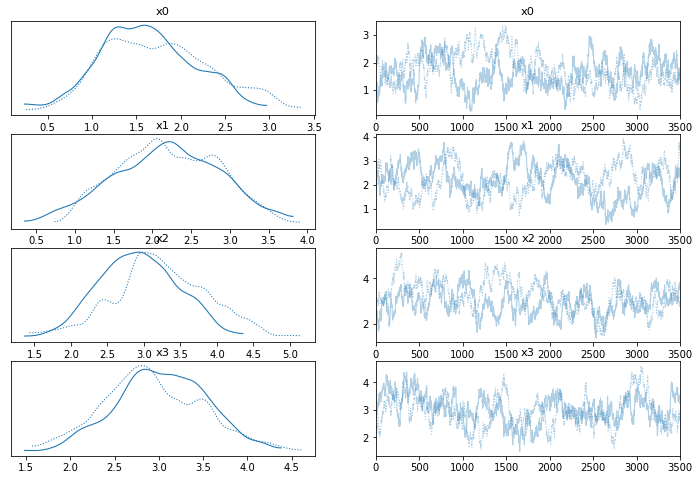

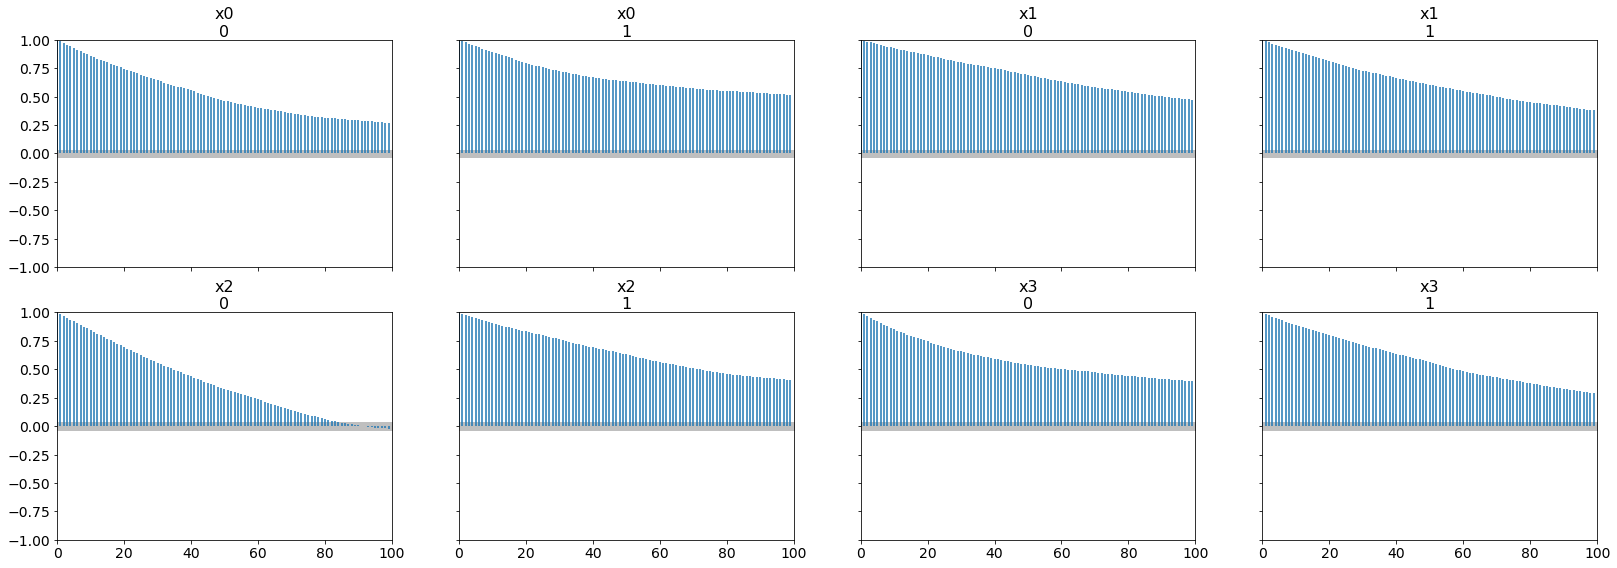

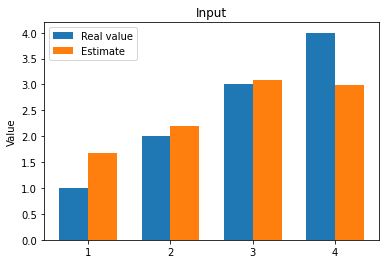

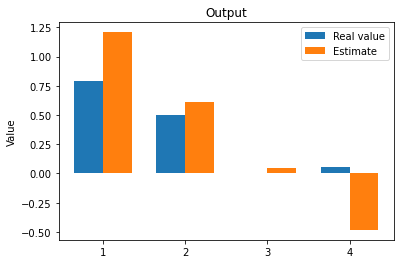

The function inverse took 1535.0250437259674 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/2


Running chain, α = 0.77: 100%|██████████| 5000/5000 [06:54<00:00, 12.05it/s]


Sampling chain 2/2


Running chain, α = 0.68: 100%|██████████| 5000/5000 [06:28<00:00, 12.86it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.06  2.599 2.541 2.702]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.060  0.598   1.081    3.354      0.118    0.095      32.0      18.0   
x1  2.599  0.595   1.643    3.696      0.087    0.063      50.0     118.0   
x2  2.541  0.495   1.654    3.563      0.085    0.060      36.0      50.0   
x3  2.702  0.541   1.895    4.055      0.074    0.060      59.0      86.0   

    r_hat  
x0   1.12  
x1   1.03  
x2   1.07  
x3   1.06  
Autocorrelation...
the estimated values are [1.06  0.599 0.459 1.298]
 the difference between outputs of two models are [0.9756806  0.2409338  0.3828995  0.23890537]


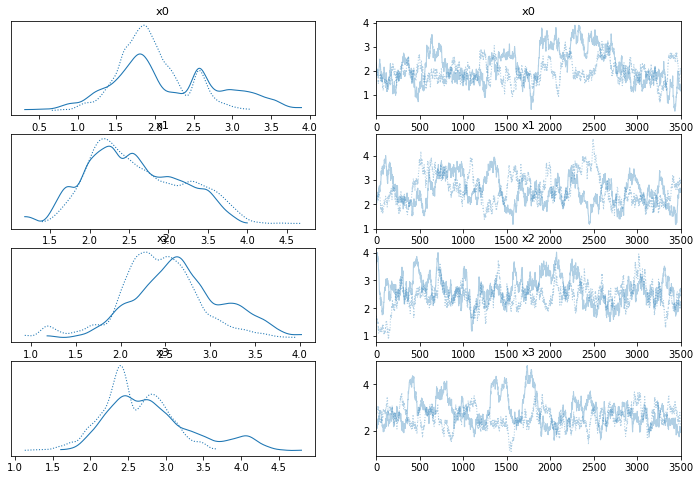

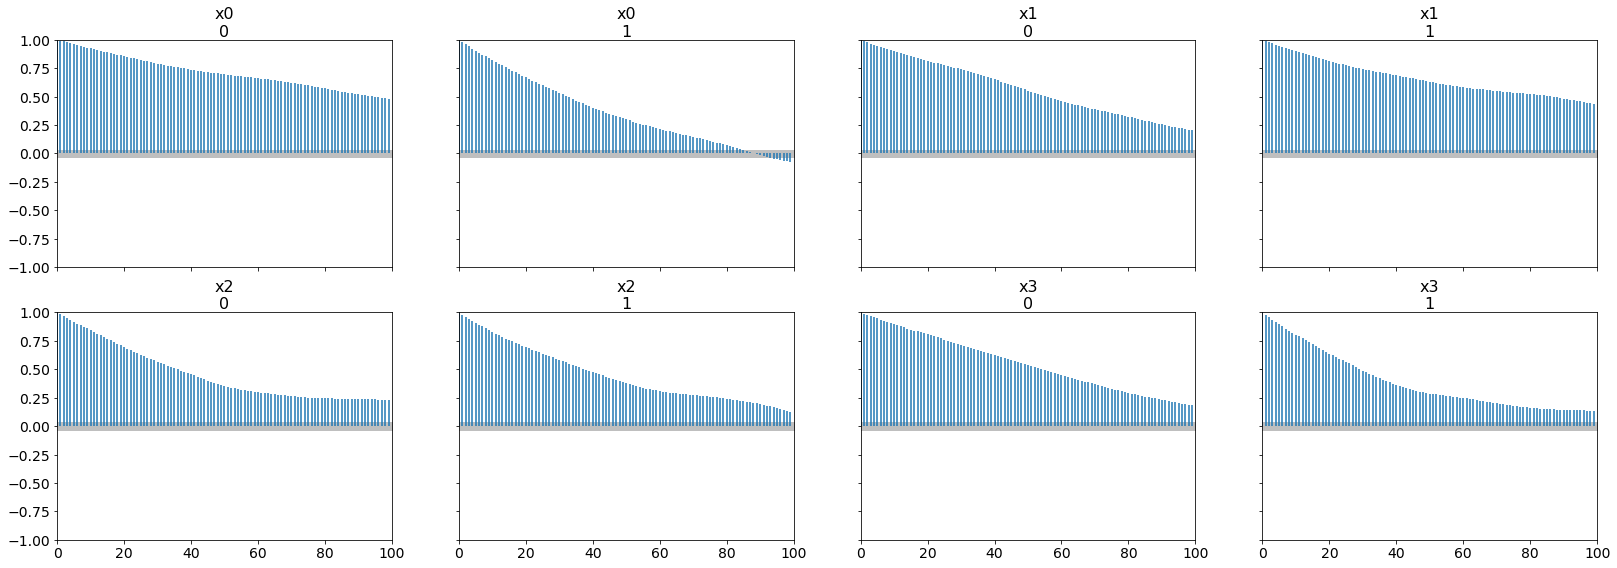

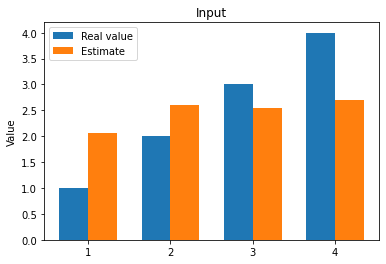

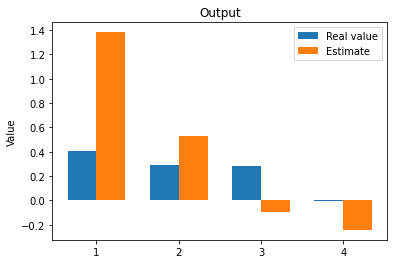

The function inverse took 811.4040796756744 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/2


Running chain, α = 0.88: 100%|██████████| 5000/5000 [06:41<00:00, 12.44it/s]


Sampling chain 2/2


Running chain, α = 0.90: 100%|██████████| 5000/5000 [07:02<00:00, 11.83it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.915 2.692 2.481 2.805]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.915  0.566   0.747    2.767      0.081    0.057      54.0     181.0   
x1  2.692  0.642   1.396    3.874      0.091    0.065      50.0      84.0   
x2  2.481  0.611   1.428    3.696      0.102    0.076      38.0      55.0   
x3  2.805  0.652   1.501    3.891      0.121    0.086      29.0      83.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.05  
x3   1.09  
Autocorrelation...
the estimated values are [0.915 0.692 0.519 1.195]
 the difference between outputs of two models are [0.3479731  0.28155708 0.3702792  0.57397956]


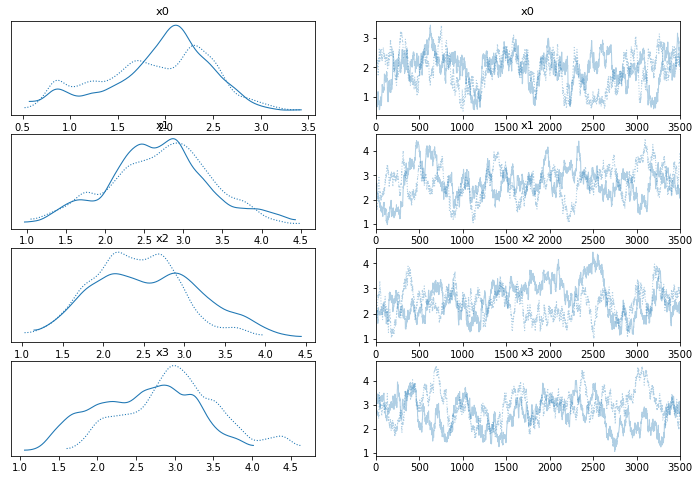

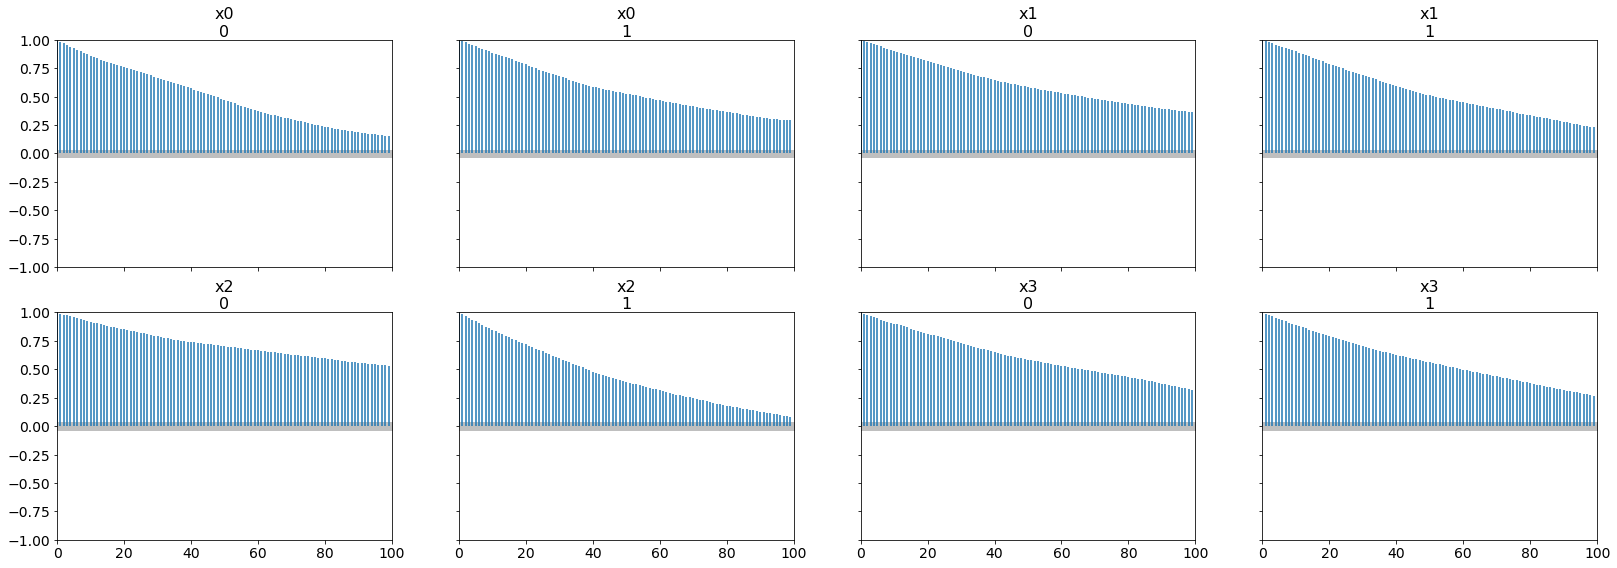

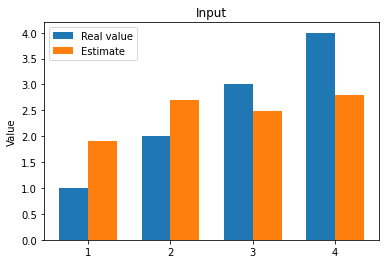

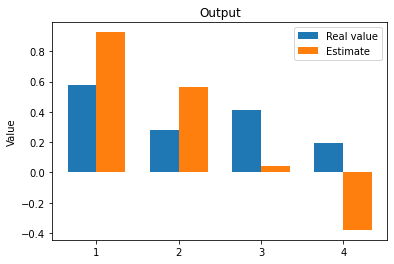

The function inverse took 828.8877708911896 seconds.


In [15]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)



real values are [1. 2. 3. 4.]
Sampling chain 1/2


Running chain, α = 1.00:   0%|          | 0/10000 [00:00<?, ?it/s]

Running chain, α = 0.41: 100%|██████████| 10000/10000 [13:14<00:00, 12.58it/s]


Sampling chain 2/2


Running chain, α = 0.40: 100%|██████████| 10000/10000 [13:52<00:00, 12.01it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


estimated values are [1.326 2.037 3.049 2.838]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.326  0.214   0.713    1.566      0.021    0.015     151.0     215.0   
x1  2.037  0.678   0.781    3.578      0.132    0.096      28.0      58.0   
x2  3.049  0.560   2.335    4.301      0.114    0.082      31.0      79.0   
x3  2.838  0.426   2.062    3.633      0.049    0.036      85.0      73.0   

    r_hat  
x0   1.04  
x1   1.10  
x2   1.09  
x3   1.02  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...


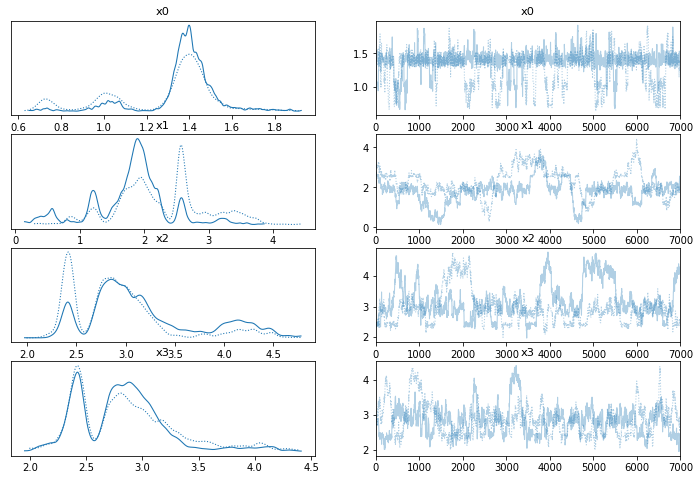

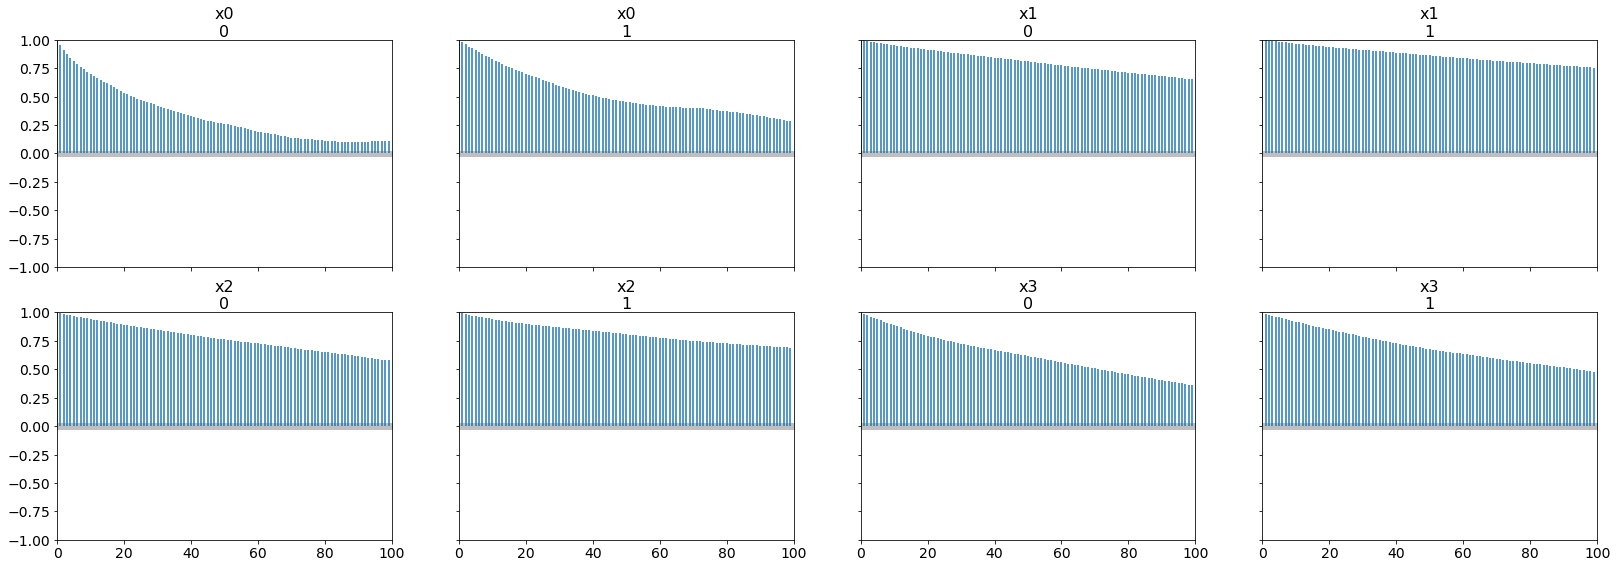

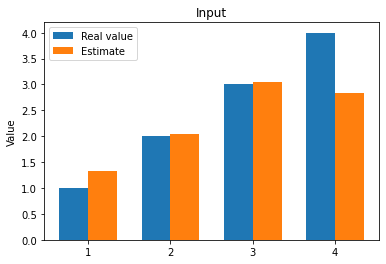

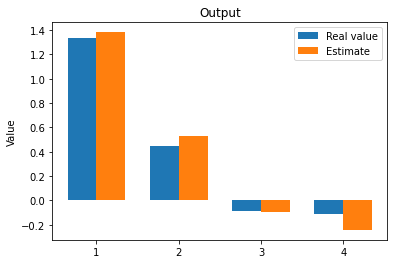

The function inverse took 1635.2999460697174 seconds.


In [ ]:
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

# High Fidelity model

real values are [1. 2. 3. 4.]
Sampling chain 1/2


Running chain, α = 0.77: 100%|██████████| 10000/10000 [13:19<00:00, 12.51it/s] 


Sampling chain 2/2


Running chain, α = 0.89: 100%|██████████| 10000/10000 [14:27<00:00, 11.53it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.896 2.775 2.353 4.66 ]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.896  0.472   0.955    2.678      0.043    0.030     125.0     298.0   
x1  2.775  0.546   1.619    3.763      0.050    0.036     120.0     259.0   
x2  2.353  0.474   1.380    3.151      0.046    0.032     109.0     270.0   
x3  4.660  0.529   3.541    5.486      0.061    0.044      80.0     236.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.03  
x3   1.06  
Autocorrelation...


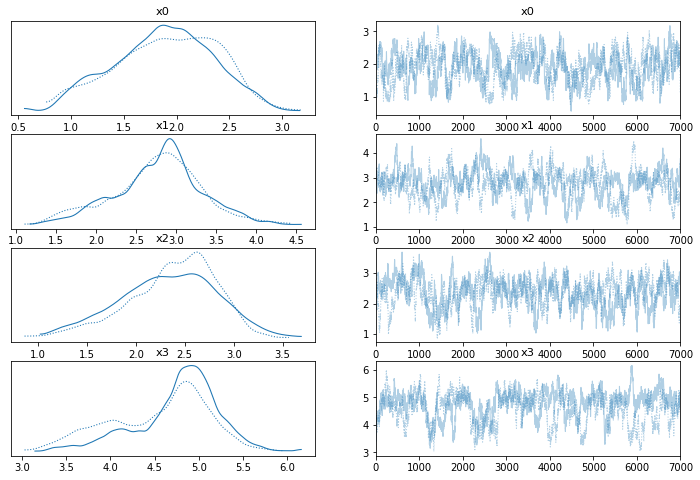

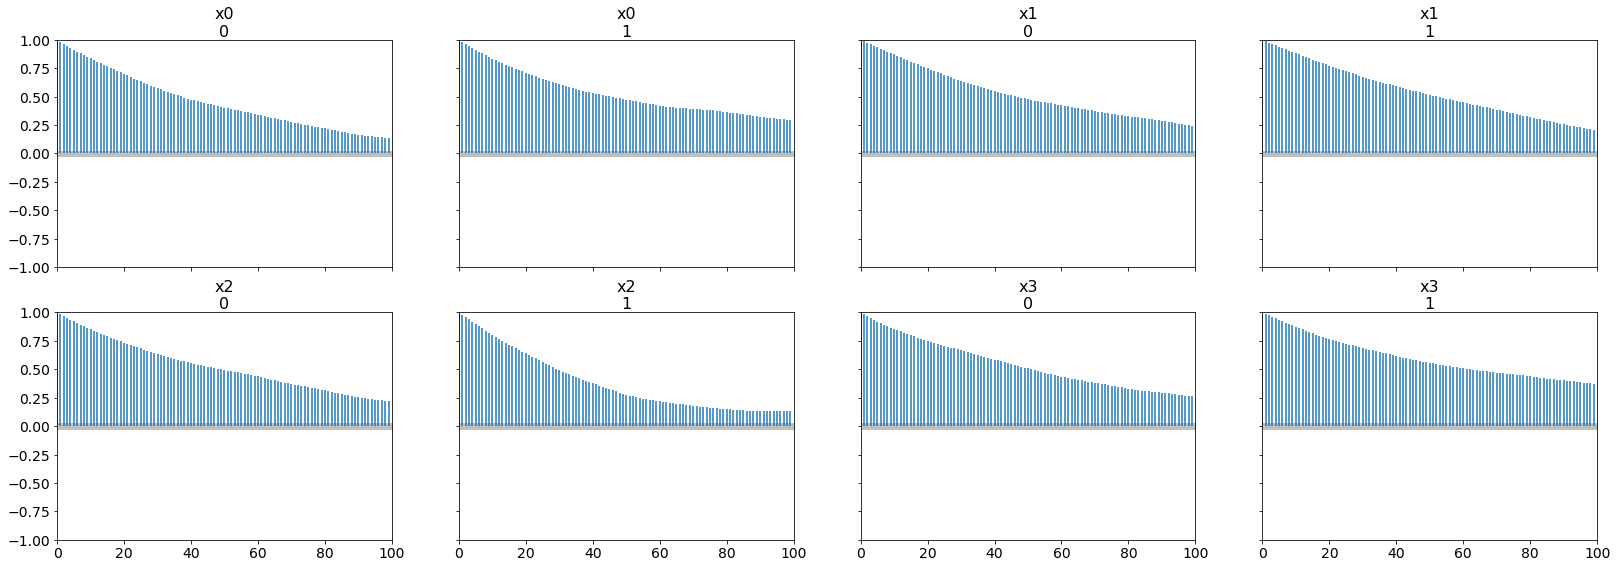

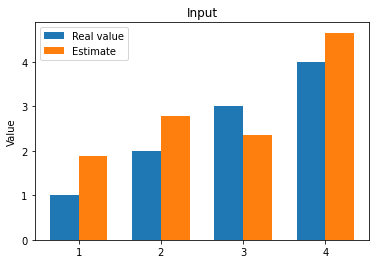

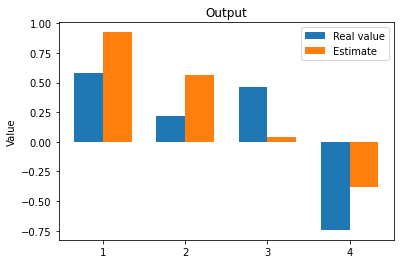

The function inverse took 1674.8463563919067 seconds.


In [ ]:
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

# Multi Fidelity model

real values are [1. 2. 3. 4.]
Sampling chain 1/2


Running chain, α = 0.83: 100%|██████████| 10000/10000 [25:22<00:00,  6.57it/s] 


Sampling chain 2/2


Running chain, α = 0.80: 100%|██████████| 10000/10000 [26:53<00:00,  6.20it/s] 
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


estimated values are [0.903 2.025 3.571 3.248]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.903  0.281   0.483    1.513      0.018    0.013     283.0     413.0   
x1  2.025  0.432   1.212    2.825      0.039    0.028     123.0     354.0   
x2  3.571  0.427   2.810    4.432      0.059    0.043      56.0     113.0   
x3  3.248  0.454   2.340    4.003      0.040    0.029     128.0     227.0   

    r_hat  
x0   1.00  
x1   1.01  
x2   1.04  
x3   1.02  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...


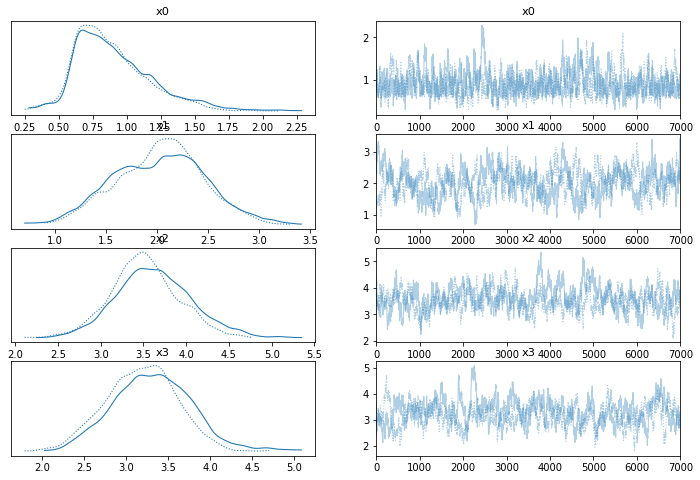

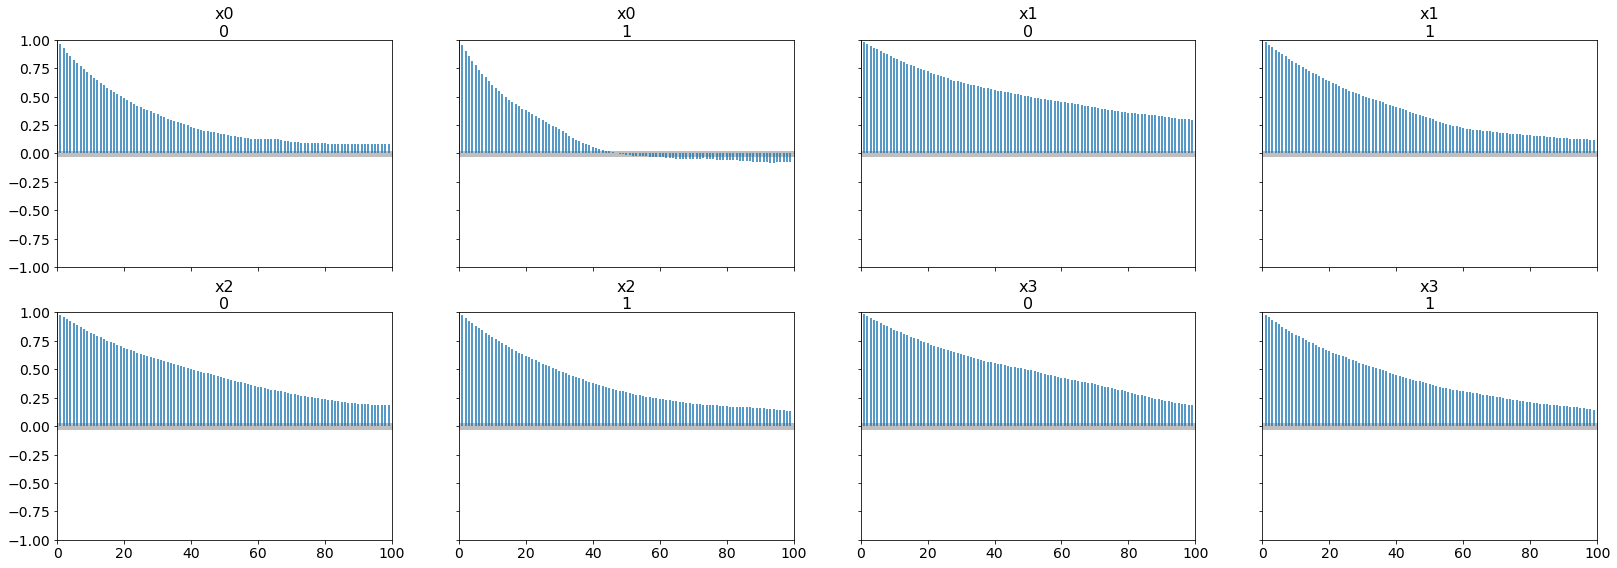

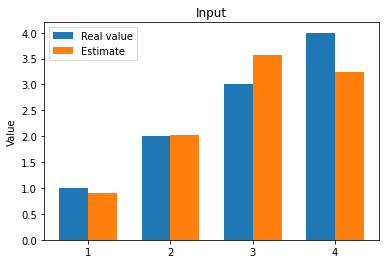

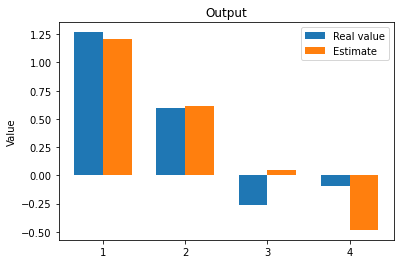

The function inverse took 3159.212464570999 seconds.


In [ ]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)